# 04 — Full Pipeline Demo (Single Card)

Combines everything: crop → detect fields → preprocess each field → OCR.
Field-specific preprocessing and Arabic reading-order correction (top-to-bottom,
right-to-left) were tuned by testing on several real cards.

The sample card shown below is a fake/parody ID card used for testing the
model (not a real person's document).

In [ ]:
CONSTANT_FIELDS = {
    "country": "جمهورية مصر العربية",
    "doc_type": "بطاقة تحقيق الشخصية"
}
# These two fields are printed identically on every card, so we skip OCR
# for them and just fill in the known value directly.

In [ ]:
import cv2

def preprocess_field(img, class_name):
    """Field-specific preprocessing before OCR (denoising, contrast, upscaling)."""
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if class_name == "image":
        return img

    if class_name == "national_id":
        img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img = clahe.apply(img)

    elif class_name in ["birth_date", "issue_date", "expire_date"]:
        img = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)
        img = cv2.fastNlMeansDenoising(img, None, 7, 7, 20)

    elif class_name == "name":
        img = cv2.resize(img, None, fx=2, fy=1.5, interpolation=cv2.INTER_CUBIC)
        img = cv2.fastNlMeansDenoising(img, None, 11, 11, 20)

    elif class_name == "address":
        img = cv2.fastNlMeansDenoising(img, None, 15, 3, 5)
        img = cv2.copyMakeBorder(img, 41, 41, 41, 41, cv2.BORDER_CONSTANT, value=255)
        img = cv2.resize(img, None, fx=2.5, fy=2.5, interpolation=cv2.INTER_CUBIC)

    elif class_name in ["gender", "religion", "martial_state", "education", "job", "husband"]:
        img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
        img = cv2.fastNlMeansDenoising(img, None, 11, 7, 20)

    else:
        img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img = clahe.apply(img)

    return img

In [ ]:
def extract_text_ordered(field_image, ocr_model, line_threshold=15):
    """
    Runs PaddleOCR and orders the detected text lines top-to-bottom, then
    right-to-left within each line — matches natural Arabic reading order.
    Without this, multi-line fields like 'name' and 'address' come back scrambled.
    """
    if len(field_image.shape) == 2:
        field_image = cv2.cvtColor(field_image, cv2.COLOR_GRAY2BGR)

    result = ocr_model.predict(field_image, use_doc_orientation_classify=False, use_doc_unwarping=False)

    if len(result) == 0 or 'rec_texts' not in result[0]:
        return []

    texts = result[0]['rec_texts']
    boxes = result[0]['rec_boxes']
    if len(texts) == 0:
        return []

    items = []
    for text, box in zip(texts, boxes):
        y_center = (box[1] + box[3]) / 2
        x_right = box[0]
        items.append((y_center, x_right, text))

    # group into lines by rounded Y, then order right-to-left within each line
    items.sort(key=lambda item: (round(item[0] / line_threshold), -item[1]))

    return [item[2] for item in items]

### Visualize each detected field crop

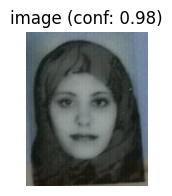

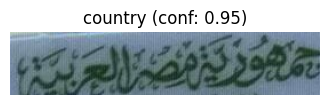

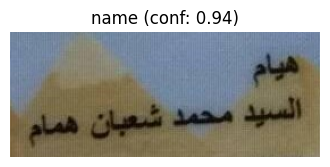

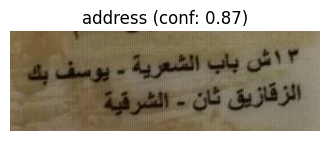

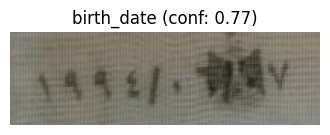

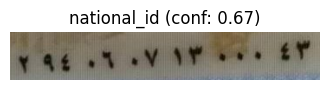

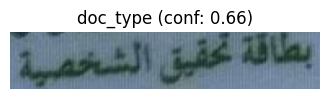

In [1]:
for field_name, data in fields.items():
    plt.figure(figsize=(4, 2))
    plt.imshow(data['image'][..., ::-1])
    plt.title(f"{field_name} (conf: {data['confidence']:.2f})")
    plt.axis('off')
    plt.show()

### Run the pipeline on a cropped card

=== final result  ===
image           → (صورة)
country         → جمهورية مصر العربية
name            → هيام السيد محمد شعبان همام
address         → ١٣ ش باب الشعرية يوسف بك الزقازيق ثان I الشرقية
birth_date      → /٠٧ ١٩٩٤١٠
national_id     → ٢٩٤٠٦٠٧١٣٠٠٠٤٣
doc_type        → بطاقة تحقيق الشخصية


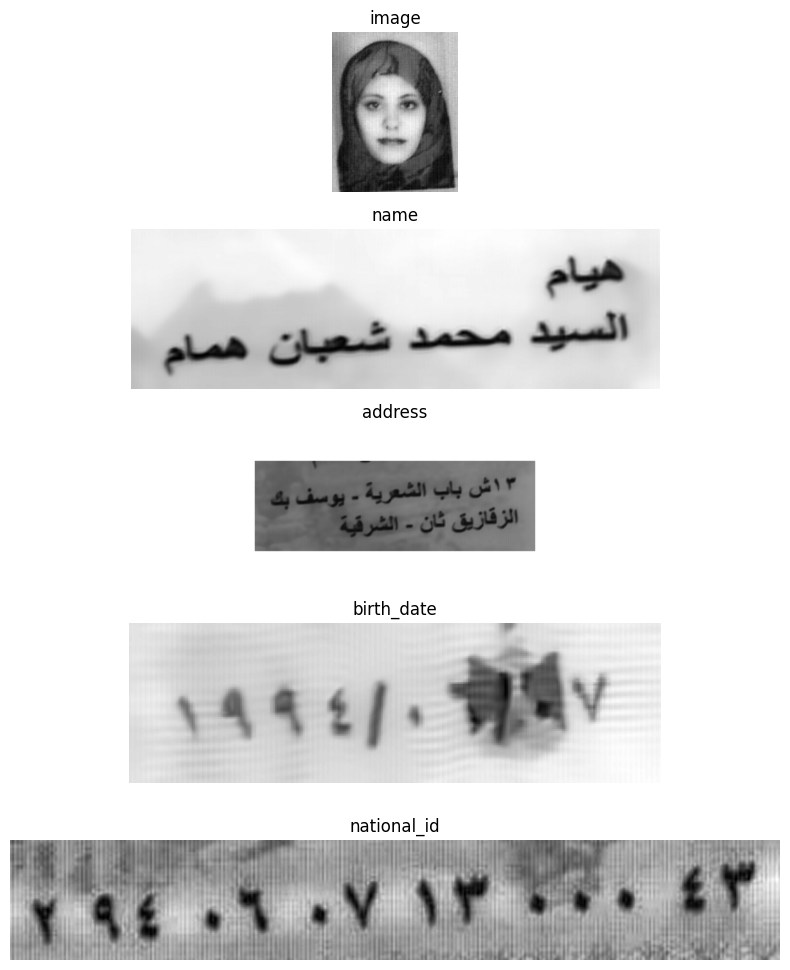

In [1]:
processed_fields = {}
final_results = {}

for field_name, data in fields.items():
    if field_name in CONSTANT_FIELDS:
        final_results[field_name] = CONSTANT_FIELDS[field_name]
        continue

    processed_img = preprocess_field(data['image'], field_name)
    processed_fields[field_name] = processed_img

    if field_name == "image":
        final_results[field_name] = "(photo)"
        continue

    texts = extract_text_ordered(processed_img, ocr)
    final_results[field_name] = " ".join(texts) if texts else "not read"

print("=== Extracted fields ===")
for field_name, text in final_results.items():
    print(f"{field_name:15s} -> {text}")

n_fields = len(processed_fields)
fig, axes = plt.subplots(n_fields, 1, figsize=(8, n_fields * 2))
if n_fields == 1:
    axes = [axes]
for ax, (field_name, img) in zip(axes, processed_fields.items()):
    ax.imshow(img, cmap='gray')
    ax.set_title(field_name)
    ax.axis('off')
plt.tight_layout()
plt.show()